In [7]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Daniel Perez Ulloa
## Due Date: April 13, 2026

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experimenty is to optimize the comfort of a new shoe model, evaluating the effects of sole material, insole thickness and fabric breathability.

2.  Specify the outcome variable and how it is measured.

The outcome variable is the comfort rating. It is measured on an ordinal scale from 1-10, 1 being very UNcomfortable, given by athletes after running for 30 minutes on a treadmill.

3.  Specify the independent variables. What lurking variables may be present?

The independent variables are sole materials, insole thickness and fabric breathability. Lurking variables include individual gait, foot type, treadmill settings, ambient room temperature.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

A full factorial design tests all possible combinations of factors at their given levels. A $2^k$ factorial design is a type of full factorial design where every factor has exactly two levels. A $2^k$ design is preferred in this case because it keeps the total number of runs in a reasonable amount while still allowing the manufacturer to estimate all main effects and interactions.

5.  State the sets of null and alternative hypotheses for this experiment.

Sets: Main effects - A, B, C, two-way interactions - AB, AC, BC, and the three way interaction - ABC.

H0: The main effect or interaction effect is equal to zero.

Ha: At least one level's main effect or interactions is not equal to zero.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

The Gel sole material appears to yield higher comfort than EVA. The 6mm insole thickness and woven breathability show higher mean comfort ratings than their counterparts. The combination of Gel sole, 6mm thickness and woven breathability yields a high average comfort rating compared to other combinations. The comfort means are distinctly different across the various levels and combinations of factors, giving support to the alternative hypothesis more than the null hypothesis.

In [8]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *


#p1q6 Import Data#
scexp = pd.read_excel("Shoe Comfort Experiment.xlsx", engine = 'openpyxl')

print("Question 6: Exploratory Data Analysis")
print(scexp.columns.tolist())
print(scexp.describe(include="all").T)

print(scexp.info())
print(scexp.head())
print(scexp.min())
print(scexp.max())

#main effects
print("Main Effects")
#sole material
sole_stats = scexp.groupby("sole_material")["comfort"].agg(['mean','std'])

print(sole_stats)

#insole thickness
insole_stats = scexp.groupby("insole_thickness")["comfort"].agg(['mean','std'])

print(insole_stats)

#breathability
breath_stats = scexp.groupby("breathability")["comfort"].agg(['mean','std'])

print(breath_stats)

#two-way interactions
print("Two-Way Interactions")
#sole x insole
sole_insole_stats = scexp.groupby(["sole_material","insole_thickness"])["comfort"].agg(['mean','std'])
print(sole_insole_stats)

#sole x breathability
sole_breath_stats = scexp.groupby(["sole_material","breathability"])["comfort"].agg(['mean','std'])
print(sole_breath_stats)

#insole x breathability
insole_breath_stats = scexp.groupby(["insole_thickness","breathability"])["comfort"].agg(['mean','std'])
print(insole_breath_stats)

#Three way interactions
print("Three-Way Interactions")

sole_insole_breath_stats = scexp.groupby(["sole_material","insole_thickness","breathability"])["comfort"].agg(['mean','std'])
print(sole_insole_breath_stats)

#prepare summarized data
scexp_means = sole_insole_breath_stats.reset_index()[['sole_material','insole_thickness','breathability', 'mean']]

box_dodge = position_dodge(0.75)

p = (
    ggplot(scexp, aes(x='sole_material',y='comfort')) +
    geom_boxplot(aes(fill='insole_thickness'), alpha = 0.7, position = box_dodge) +
    #mean points
    geom_point(
        data=scexp_means,
        mapping=aes(y='mean', group='sole_material'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black',
    ) +
#mean lines
    geom_line(
        data=scexp_means,
        mapping=aes(y='mean', group='sole_material', color='sole_material'),
        size=1.2,
        position=box_dodge
    ) +
    #facet by breathability
    facet_wrap('~breathability', ncol=2) +
    #format
    labs(title = "Shoe Comfort by Sole material, insole thickness and breathability",
    x = "Sole Material",
    y = "Comfort Rating",
    fill = "insole_thickness",
    color = "insole_thickness") +

    theme_classic() +
    theme(
        plot_title = element_text(hjust=0.5),
        strip_text = element_text(size=11, weight='bold')
    ) +

    scale_y_continuous(limits=(2.5, 12))
)



Question 6: Exploratory Data Analysis
['sole_material', 'insole_thickness', 'breathability', 'comfort']
                 count unique    top freq   mean       std  min   25%  50%  \
sole_material       24      2    EVA   12    NaN       NaN  NaN   NaN  NaN   
insole_thickness    24      2    3mm   12    NaN       NaN  NaN   NaN  NaN   
breathability       24      2  Woven   12    NaN       NaN  NaN   NaN  NaN   
comfort           24.0    NaN    NaN  NaN  8.075  1.635543  5.2  6.85  8.0   

                    75%   max  
sole_material       NaN   NaN  
insole_thickness    NaN   NaN  
breathability       NaN   NaN  
comfort           8.825  11.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   com

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?

Using a visual method of QQ plot, the assumption of normality is maintained. The residuals are seen equally distributed around the ab line, with no particular spot that is too extreme. Using the Shapiro - Wilks test, we calculated a p-value of 0.3903, failing to reject the null hypothesis.

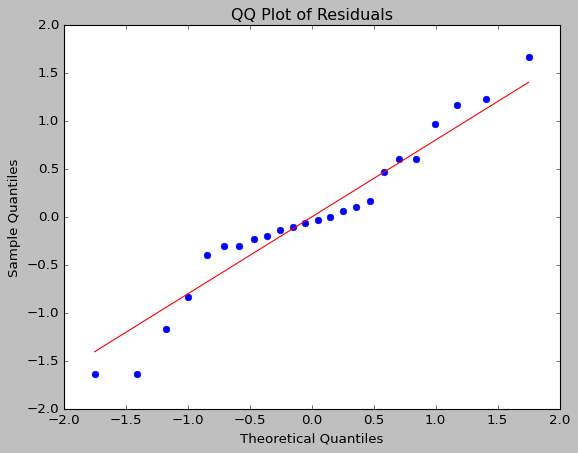

Shapiro-Wilk Test Results:
Statistic: 0.9575037531835807
p-value: 0.39035284823506383
Fail to reject the null hypothesis - Residuals are normally distributed.


In [9]:
## Question 7 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

model = ols('comfort ~ sole_material * insole_thickness * breathability', data=scexp).fit()

residuals = model.resid

#test normality
#QQ plot
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

#shapiro wilks test

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


A visual method of scatterplot of Standardized residuals vs fitted values values was analyzed, showing symmetrical values around the line. This is evidence to support the assumption of constant variance. Using a testing method of Breusch-pagan testing, a p-value of 0.0818 was calculated, which is higher than an alpha of 0.05, which fails to reject the null hypothesis.

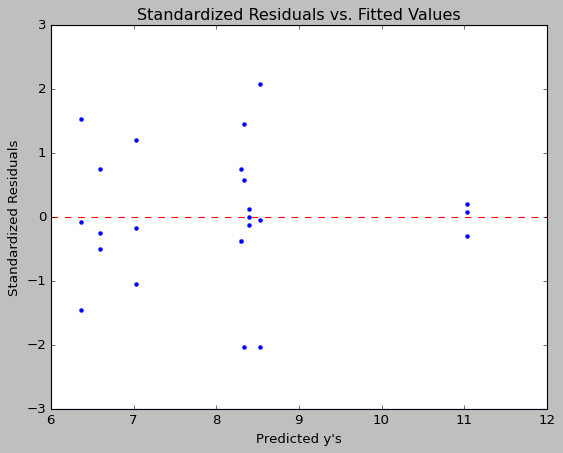

F-statistic: 2.278431684215503
F p-value: 0.0818079385294926
Fail to reject the null hypothesis - Variances are equal.


In [10]:
## Question 8 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

#Scatterplot of Standardized Residuals vs. Fitted Values

#standardized Residuals

standardized_residuals = model.get_influence().resid_studentized_internal

#fit values

fitted_values = model.fittedvalues

#scatterplot


plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

#B-P Test

bp_test = het_breuschpagan(residuals, model.model.exog)

f_statistic = bp_test[2]

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?

Based on the ANOVA table, the main effect of sole material is statistically significant (F = 5.812, p = 0.0282). The main effects for insole_thickness(F = 0.691, p = 0.4180) and breathability (F = 0.00846, p = 0.7748) are not statistically significant. None of the two-way or three-way interactions are statistically significant as all the p-values are greater than 0.05. We can conclude that only the choice of sole material has a signficant main effect on shoe comfort.



In [11]:
## Question 9 Code ##


anova_table = sm.stats.anova_lm(model, typ=3)

#Add Significance Column#

anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")

print(anova_table.drop(index=["Intercept", "Residual"]))

                                                    sum_sq   df             F  \
sole_material                                 5.606667e+00  1.0  5.812527e+00   
insole_thickness                              6.666667e-01  1.0  6.911447e-01   
breathability                                 8.166667e-02  1.0  8.466523e-02   
sole_material:insole_thickness                3.008333e-01  1.0  3.118790e-01   
sole_material:breathability                   9.466331e-30  1.0  9.813907e-30   
insole_thickness:breathability                9.633333e-01  1.0  9.987041e-01   
sole_material:insole_thickness:breathability  6.666667e-01  1.0  6.911447e-01   

                                                PR(>F)     Significance  
sole_material                                 0.028297      Significant  
insole_thickness                              0.418010  Not Significant  
breathability                                 0.774810  Not Significant  
sole_material:insole_thickness                0.584261 


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?

The partial η2 values indicate the proportion of variance explained by each factor while controlling for others:
*   sole_material: 0.5965
*   insole_thickness: 0.3779
*   breathability: 0.3330
*   insole_thickness * breathability: 0.2395
*   All other interactions have very low values (< 0.05).

The most important effect is sole material as it explains the largest proportion of variance in comfort ratings and is the only statistically significant effect. The main effect of insole thickness and the interaction between insole thickness and breathability also show large effect sizes, but did not reach statistical significance in ANOVA testing.

In [15]:
## Question 10 Code ##
%pip install pingouin
import statsmodels.api as sm
import pingouin as pg

mod_p = pg.anova(dv='comfort',between=["sole_material","insole_thickness","breathability"],data=scexp,effsize="np2").round(4)

print(mod_p[["Source","np2"]])


                                             Source     np2
0                                     sole_material  0.5965
1                                  insole_thickness  0.3779
2                                     breathability  0.3330
3                  sole_material * insole_thickness  0.0001
4                     sole_material * breathability  0.0414
5                  insole_thickness * breathability  0.2395
6  sole_material * insole_thickness * breathability  0.0414
7                                          Residual     NaN



11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

I would recommend the shoe manufacturer implement a design featuring Advanced gel-infused foam for the sole material, 6mm insole thickness and standard woven fabric for breathability. This was the combination that had the highest observed comfort, and the sole material was found to be the most statistically significant. This shoe combination would offer the best potential for most user comfort based on this data.

## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to compare the three specifications of a GPS-enabled fitness band -  GPS accuracy, battery life and Display size and their effects on runner satisfaction.

2.  Specify the outcome variable and how it is measured.

The outcome variable is satisfaction rating. It is measured on an ordinal scale from 1-10, with 1 being least satisfied and 10 being most satisfied.

3.  Specify the independent variables. What lurking variables may be present?

The independent variables in this experiment are GPS accuracy, battery life and Display size. Lurking variables may be the size of the band, the placement of the watch/ the differences in runners' skins, maybe even phone type.

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

Typically, in fractional factorial designs, we rely on the sparsity of effects principle, which assumes that main effects are much more likely to be significant than two-way interactions. Therefore, if the $A + BC$$A + BC$ effect is significant, we usually attribute it entirely to the main effect $A$$A$, assuming the interaction $BC$$BC$ is negligible.

5.  State the sets of null and alternative hypotheses for this experiment.

The null and alternative hypotheses for each aliased effect are:

For Effect (A + BC):
*   H0: The combined effect of GPS Accuracy and the interaction between Battery Life and Display is equal to zero.
*   Ha: The combined effect of GPS Accuracy and the interaction between Battery Life and Display is not equal to zero.

For Effect (B + AC):
*   H0: The combined effect of Battery Life and the interaction between GPS Accuracy and Display is equal to zero.
*   Ha: The combined effect of Battery Life and the interaction between GPS Accuracy and Display is not equal to zero.

For Effect (C + AB):
*   H0: The combined effect of Display and the interaction between GPS Accuracy and Battery Life is equal to zero.
*   Ha: The combined effect of Display and the interaction between GPS Accuracy and Battery Life is not equal to zero.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

Given the defining relation $I=ABC$, the aliasing structure is as follows:
*   $A = BC$
*   $B = AC$
*   $C = AB$

*   Main Effect A is aliased with the BC interaction ($A \equiv BC$)
*   Main Effect B is aliased with the AC interaction ($B \equiv AC$)
*   Main Effect C is aliased with the AB interaction ($C \equiv AB$)

Because these effects are aliased (or "confounded"), you cannot mathematically separate them. When you calculate the effect for Factor A, you are actually calculating the combined effect of $A + BC$$A + BC$.

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

The results of the exploratory data analysis boxplots show that the higher GPS accuracy level appears to have higher satisfaction ratings than the standard level, the 12 hours battery life shows higher satisfaction ratings compared to the 6 hour level, and the large display shows a trend in higher satisfaction ratings compared to the small display size. Looking at the means differences of each independent variable, they coincide with what is seen in the boxplots. These analyses support the alternative more strongly.


Question 7: Exploratory Data Analysis
['Run_ID', 'Replicate', 'GPS_Accuracy', 'Battery_Life', 'Display', 'Satisfaction']
             count unique       top freq      mean       std   min   25%  \
Run_ID        12.0    NaN       NaN  NaN       2.5  1.167748   1.0  1.75   
Replicate     12.0    NaN       NaN  NaN       2.0  0.852803   1.0   1.0   
GPS_Accuracy    12      2  Standard    6       NaN       NaN   NaN   NaN   
Battery_Life    12      2   6 Hours    6       NaN       NaN   NaN   NaN   
Display         12      2     Large    6       NaN       NaN   NaN   NaN   
Satisfaction  12.0    NaN       NaN  NaN  5.873333  2.236732  3.19  4.48   

               50%    75%   max  
Run_ID         2.5   3.25   4.0  
Replicate      2.0    3.0   3.0  
GPS_Accuracy   NaN    NaN   NaN  
Battery_Life   NaN    NaN   NaN  
Display        NaN    NaN   NaN  
Satisfaction  5.25  6.725  9.55  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   C

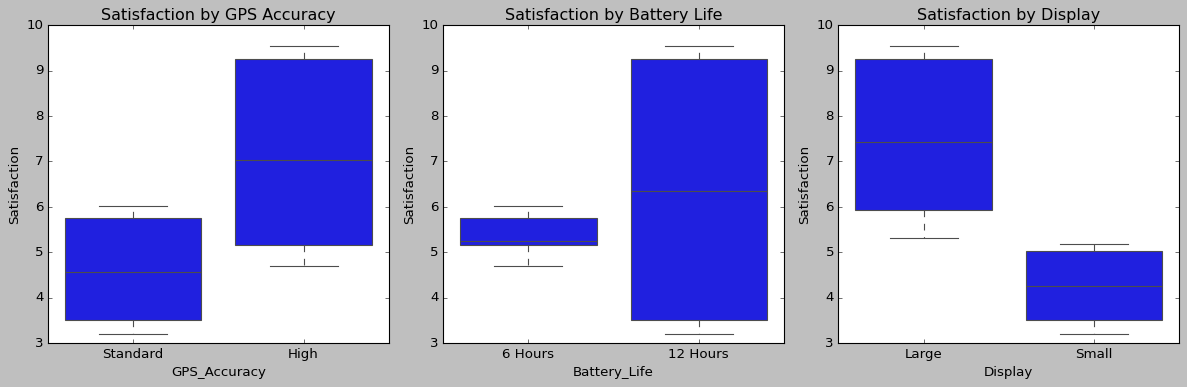

In [16]:
## Question 7 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *


#p2q7 Import Data#
gpsxp = pd.read_excel("Fitness Band Experiment.xlsx", engine = 'openpyxl')

print("Question 7: Exploratory Data Analysis")
print(gpsxp.columns.tolist())
print(gpsxp.describe(include="all").T)

print(gpsxp.info())

print(gpsxp.head())
print(gpsxp.min())
print(gpsxp.max())


#main effects
print("Main Effects")

gps_stats = gpsxp.groupby("GPS_Accuracy")["Satisfaction"].agg(['mean','std'])

print(gps_stats)

bat_stats = gpsxp.groupby("Battery_Life")["Satisfaction"].agg(['mean','std'])

print(bat_stats)

disp_stats = gpsxp.groupby("Display")["Satisfaction"].agg(['mean','std'])

print(disp_stats)

#Create boxplots for main effects
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='GPS_Accuracy', y='Satisfaction', data=gpsxp)
plt.title('Satisfaction by GPS Accuracy')

plt.subplot(1, 3, 2)
sns.boxplot(x='Battery_Life', y='Satisfaction', data=gpsxp)
plt.title('Satisfaction by Battery Life')

plt.subplot(1, 3, 3)
sns.boxplot(x='Display', y='Satisfaction', data=gpsxp)
plt.title('Satisfaction by Display')

plt.tight_layout()
plt.show()


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?

Using a visual method of QQ plot, the assumption of normality is maintained. The residuals are seen equally distributed around the ab line, with no particular spot that is too extreme. Using the Shapiro - Wilks test, we calculated a p-value of 0.09106, failing to reject the null hypothesis.

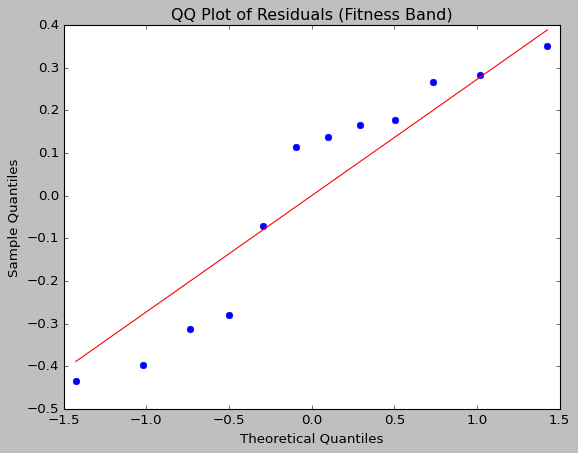

Shapiro-Wilk Test Results:
Statistic: 0.8812973148236574
p-value: 0.09106712364387089
Fail to reject the null hypothesis - Residuals are normally distributed.


In [17]:
## Question 8 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import matplotlib.pyplot as plt

# Fit the ANOVA model (Main effects only)
model2 = ols('Satisfaction ~ GPS_Accuracy + Battery_Life + Display', data=gpsxp).fit()

#get residuals
residuals2 = model2.resid

#QQ Plot
sm.qqplot(residuals2, line='s')
plt.title('QQ Plot of Residuals (Fitness Band)')
plt.show()

#Shapiro-Wilk Test
shapiro_test2 = stats.shapiro(residuals2)
print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test2.statistic}")
print(f"p-value: {shapiro_test2.pvalue}")

if shapiro_test2.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?

A visual method of scatterplot of Standardized residuals vs fitted values values was analyzed, showing symmetrical values around the line. This is evidence to support the assumption of constant variance. Using a testing method of Levene's testing, a p-value of 0.9872 was calculated, which is higher than an alpha of 0.05, which fails to reject the null hypothesis.

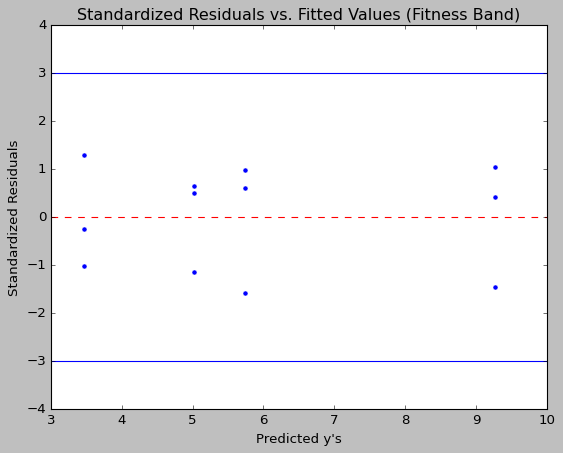

Levene's Test Results:
Statistic: 0.0431764375426348
p-value: 0.9871757768502188
Fail to reject the null hypothesis - Variances are equal.


In [18]:
## Question 9 Code ##
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

#Standardized Residuals vs. Fitted Values plot
standardized_residuals2 = model2.get_influence().resid_studentized_internal
fitted_values2 = model2.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values2, y=standardized_residuals2)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values (Fitness Band)")
plt.show()

#Levene's Test
groups = [gpsxp['Satisfaction'][gpsxp['Run_ID'] == i] for i in gpsxp['Run_ID'].unique()]
levene_stat, levene_p = stats.levene(*groups)

print("Levene's Test Results:")
print(f"Statistic: {levene_stat}")
print(f"p-value: {levene_p}")

if levene_p < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?


Based on the ANOVA table, the main effects of GPS accuracy (F = 172.87, p < 0.01), battery life (F = 26.4, p < 0.01) and Display (F = 286.85, p < 0.01) are all statistically significant. We can conclude that all 3 main effects are significant for runner satisfaction.

In [19]:
## Question 10 Code ##
import statsmodels.api as sm
import numpy as np

# ANOVA
anova_table2 = sm.stats.anova_lm(model2, typ=2)

# Add Significance Column
anova_table2["Significance"] = np.where(anova_table2["PR(>F)"] < 0.05, "Significant", "Not Significant")

# Print Table
print(anova_table2)

                 sum_sq   df           F        PR(>F)     Significance
GPS_Accuracy  19.253333  1.0  172.869435  1.065588e-06      Significant
Battery_Life   2.940300  1.0   26.400000  8.872097e-04      Significant
Display       31.948033  1.0  286.851029  1.498222e-07      Significant
Residual       0.891000  8.0         NaN           NaN  Not Significant


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

Based on our calculations:
*   GPS Accuracy Main Effect: 2.5333
*   Battery Life Main Effect: 0.990
*   Display Main Effect: 3.2633

All main effects are positive, meaning that moving from the low/standard level to the high level increases user satisfaction. The Display and GPS Accuracy effects seem most important because their values are much larger, indicating they drive a greater increase in satisfaction compared to Battery Life.

In [20]:
## Question 11 Code ##
# Calculate values for the main effects (Mean of High level - Mean of Low level)

gps_effect = gpsxp[gpsxp['GPS_Accuracy'] == 'High']['Satisfaction'].mean() - gpsxp[gpsxp['GPS_Accuracy'] == 'Standard']['Satisfaction'].mean()
battery_effect = gpsxp[gpsxp['Battery_Life'] == '12 Hours']['Satisfaction'].mean() - gpsxp[gpsxp['Battery_Life'] == '6 Hours']['Satisfaction'].mean()
display_effect = gpsxp[gpsxp['Display'] == 'Large']['Satisfaction'].mean() - gpsxp[gpsxp['Display'] == 'Small']['Satisfaction'].mean()

print(f"GPS Accuracy Main Effect: {gps_effect:.4f}")
print(f"Battery Life Main Effect: {battery_effect:.4f}")
print(f"Display Main Effect: {display_effect:.4f}")

GPS Accuracy Main Effect: 2.5333
Battery Life Main Effect: 0.9900
Display Main Effect: 3.2633


12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

Based on our calculations, the partial $\eta^2$ values are:
*   GPS Accuracy: 0.9558
*   Battery Life: 0.7674
*   Display: 0.9729

These values represent the proportion of variance in user satisfaction explained by each factor while controlling for the other factors in the model.

The Display (0.9729) and GPS Accuracy (0.9558) effects are the most important, as they have the largest effect sizes, explaining over 93% of the remaining variance in satisfaction. Battery Life is also important with a large effect size (0.7674), but it is relatively less impactful than the other two factors.

In [22]:
## Question 12 Code ##
import pingouin as pg

#Calculate partial eta-squared for the main effects
mod2_p = pg.anova(dv='Satisfaction', between=['GPS_Accuracy', 'Battery_Life', 'Display'], data=gpsxp, effsize="np2").round(4)
print(mod2_p[['Source', 'np2']])

                                  Source     np2
0                           GPS_Accuracy  0.9558
1                           Battery_Life  0.7674
2                                Display  0.9729
3            GPS_Accuracy * Battery_Life  0.9729
4                 GPS_Accuracy * Display  0.7674
5                 Battery_Life * Display  0.9558
6  GPS_Accuracy * Battery_Life * Display  0.9979
7                               Residual     NaN


13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

 All three factors (GPS Accuracy, Battery Life, and Display) significantly improve user satisfaction when set to their higher levels. I would recommend the manufacturer produce a fitness band with High gps accuract, 12 hours of battery life, and a large display. Since all main effects are positive and statistically significant, this combination will maximize user satisfaction based on the experimental data.